In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [3]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [4]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


<Axes: xlabel='Length1', ylabel='Weight'>

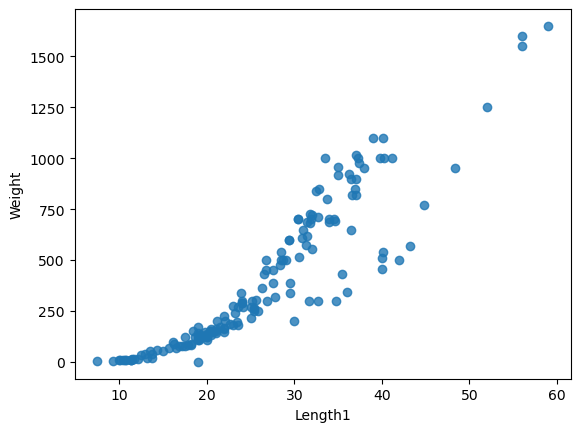

In [5]:
sns.regplot(data=df,x='Length1',y="Weight",fit_reg=False)

<Axes: xlabel='Length1', ylabel='Weight'>

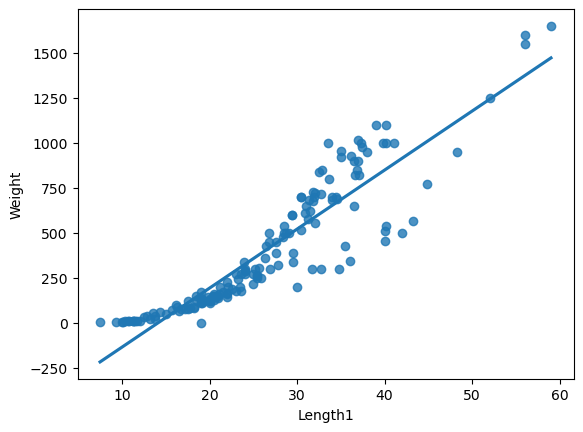

In [6]:
sns.regplot(data=df,x='Length1',y="Weight",ci=None)

<Axes: xlabel='Length1', ylabel='Weight'>

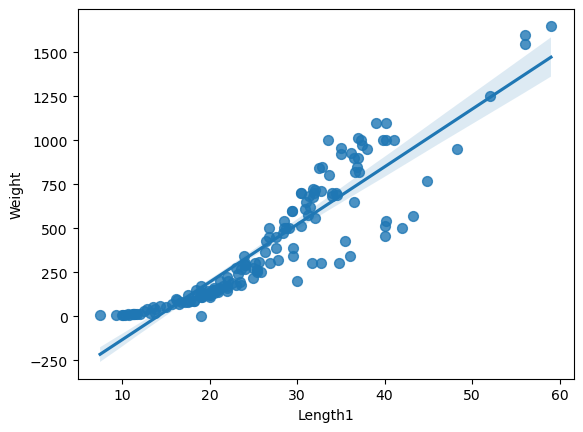

In [7]:
sns.regplot(data=df,x='Length1',y="Weight",scatter_kws={'s':50})

In [8]:
#For Predicting weight from length1
x=df[['Length1']]
y=df[["Weight"]]

In [9]:
#Split into 2 part train and test
from sklearn.model_selection import train_test_split

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print('X_train')
print(x_train)
print('X_test')
print(x_test)
print('y_train')
print(y_train)
print('y_test')
print(y_test)

(127, 1)
(32, 1)
(127, 1)
(32, 1)
X_train
     Length1
75      15.0
138     43.2
2       23.9
86      20.0
45      20.5
..       ...
71      24.0
106     25.9
14      29.4
92      20.5
102     25.2

[127 rows x 1 columns]
X_test
     Length1
78      16.8
155     11.7
128     30.0
55      23.6
94      21.0
29      33.5
147     10.1
51      23.6
98      22.6
141     52.0
19      31.0
60      37.3
15      29.4
65      18.4
24      31.9
30      35.0
126     40.2
101     25.0
96      22.0
16      30.4
151     11.3
18      30.9
12      29.1
9       28.5
31      35.0
125     40.1
95      21.5
56      24.1
145      9.3
152     11.3
135     40.0
76      15.7
y_train
     Weight
75     51.5
138   567.0
2     340.0
86    120.0
45    160.0
..      ...
71    300.0
106   250.0
14    600.0
92    150.0
102   300.0

[127 rows x 1 columns]
y_test
     Weight
78     78.0
155    13.4
128   200.0
55    270.0
94    150.0
29   1000.0
147     7.0
51    180.0
98    188.0
141  1250.0
19    650.0
60   1000.0
15 

In [12]:
#Build a model
from sklearn.linear_model import LinearRegression

In [13]:
model=LinearRegression()

In [14]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
model. coef_  #it is m in y = mx+c  (m)

array([[32.44308998]])

In [16]:
model.intercept_   #it is c in y = mx+c  (c)

array([-464.13411601])

In [17]:
y_pred=model.predict(x_test)
y_pred

array([[  80.9097957 ],
       [ -84.54996321],
       [ 509.15858348],
       [ 301.52280759],
       [ 217.17077363],
       [ 622.70939842],
       [-136.45890718],
       [ 301.52280759],
       [ 269.07971761],
       [1222.9065631 ],
       [ 541.60167346],
       [ 745.99314035],
       [ 489.69272949],
       [ 132.81873968],
       [ 570.80045445],
       [ 671.37403339],
       [ 840.0781013 ],
       [ 346.94313356],
       [ 249.61386362],
       [ 522.13581947],
       [ -97.5271992 ],
       [ 538.35736446],
       [ 479.95980249],
       [ 460.4939485 ],
       [ 671.37403339],
       [ 836.83379231],
       [ 233.39231862],
       [ 317.74435258],
       [-162.41337917],
       [ -97.5271992 ],
       [ 833.58948331],
       [  45.22239672]])

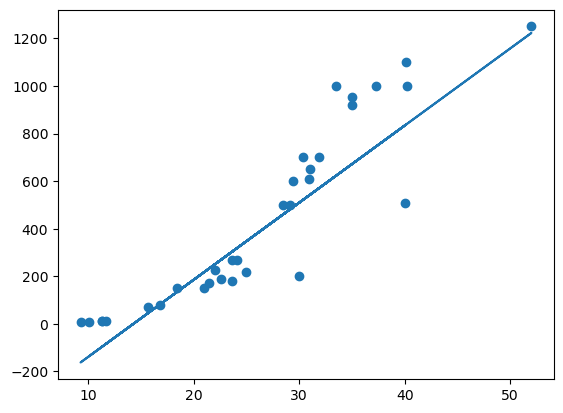

In [18]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)
plt.show()

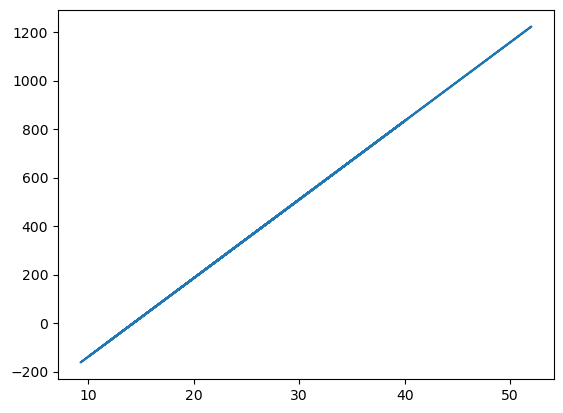

In [19]:
plt.plot(x_test,y_pred)
# plt.scatter(x_test,y_test)
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [21]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

129.36788419512138
26796.684740821387
0.8116084146869396


In [22]:
model.predict([[25]])

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[346.94313356]])

In [1]:
#Ex 2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("Fish.csv")
print(df.columns)
df

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [49]:
x=df.drop(['Species',"Weight"],axis=1)
y=df[["Weight"]]

In [50]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

109.0632714203943
21303.013279012113
0.8679594534557271


In [53]:
#Ex 3
df=pd.read_csv("Fish.csv")
x=df.drop(['Species',"Weight"],axis=1)
y=df[["Weight"]]
test=[0.75,0.80,0.85,0.90,0.95]
mse=[]
r2=[]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
print(mse)
print(r2)
plt.plot(test,r2)
plt.plot(test,mse)

[21485.14792353189, 19141.389851256346, 24762.671477245258, 20643.648028028125, 48861.047183691735]
[0.8482152077173417, 0.8607660310160297, 0.8173371854115964, 0.8468087122619059, 0.6289837470636086]


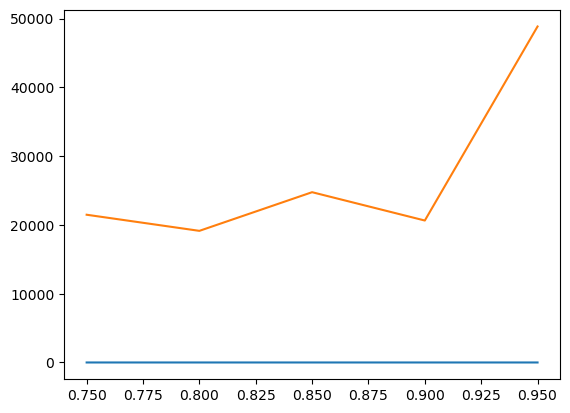

In [56]:
plt.plot(test,r2)
plt.plot(test,mse)

In [60]:
df=pd.read_csv("Ice_cream selling data.csv")

In [63]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [64]:
x=df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

14.28681469049703
288.6596992061606
-0.4122082415321706


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

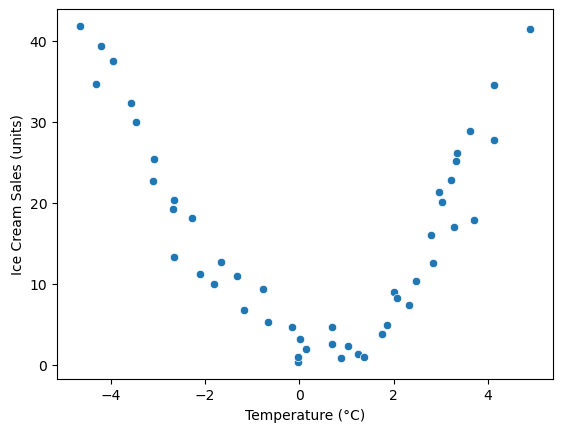

In [65]:
sns.scatterplot(data=df,x="Temperature (°C)",y="Ice Cream Sales (units)")

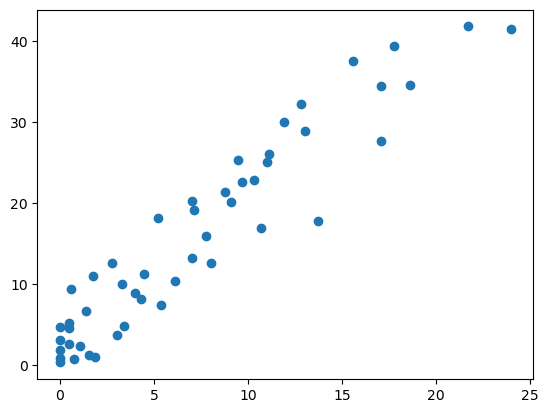

In [66]:
plt.scatter(df["Temperature (°C)"]*df["Temperature (°C)"],df["Ice Cream Sales (units)"])

In [67]:
x=df[["Temperature (°C)"]]*df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

4.527220044672891
27.28721522115138
0.8665029086853921


In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

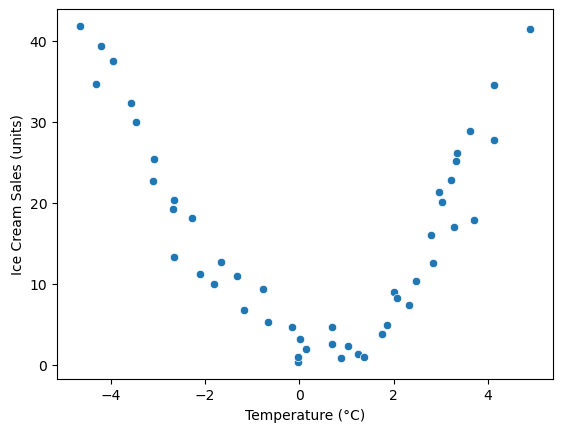

In [7]:
df=pd.read_csv("Ice_cream selling data.csv")
sns.scatterplot(data=df,x="Temperature (°C)",y="Ice Cream Sales (units)")

In [11]:
x=df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### Convert polynomial data

In [14]:
poly=PolynomialFeatures(degree=2)

In [15]:
x_train_poly=poly.fit_transform(x_train)

In [16]:
x_train_poly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [17]:
x_test_poly=poly.transform(x_test)

In [18]:
x_test_poly

array([[ 1.        , -1.81893761,  3.30853403],
       [ 1.        ,  3.70405744, 13.72004151],
       [ 1.        ,  4.13353379, 17.08610158],
       [ 1.        ,  3.61077848, 13.03772121],
       [ 1.        , -0.77333004,  0.59803936],
       [ 1.        ,  1.02418081,  1.04894634],
       [ 1.        ,  0.87490503,  0.76545881],
       [ 1.        ,  0.69359887,  0.4810794 ],
       [ 1.        ,  1.85055193,  3.42454243],
       [ 1.        , -0.14963487,  0.02239059]])

In [19]:
model=LinearRegression()
model.fit(x_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
model.coef_

array([[ 0.        , -0.70641926,  1.87145125]])

In [21]:
model.intercept_

array([2.76830583])

In [22]:
y_pred=model.predict(x_test_poly)
print(r2_score(y_pred,y_test))

0.8666323293264795


In [23]:
model.predict(poly.transform([[15]]))

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[413.24854806]])

In [68]:
df=pd.read_csv("Fish.csv")

In [69]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [70]:
y=df[["Weight"]]
x=df.drop(['Species',"Weight"],axis=1)

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
r2=[]
r2_max=0
for i in range (2,8):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    r2.append(r2_score(y_pred,y_test))
    if r2_max<r2_score(y_pred,y_test):
        r2_max=r2_score(y_pred,y_test)
        y_ans=model.predict(poly.transform([[12,13,15,5,5]]))
print(y_ans)

[[349.73726572]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
